In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
iris_df = sns.load_dataset('iris')
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


<Axes: xlabel='sepal_length', ylabel='petal_length'>

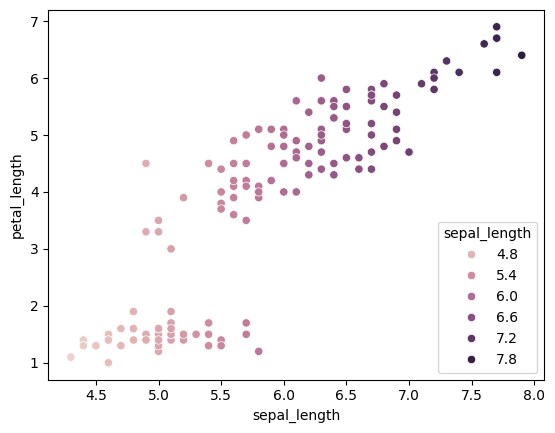

In [3]:
sns.scatterplot(data=iris_df, x='sepal_length', y='petal_length', hue='sepal_length')

<Axes: xlabel='sepal_length', ylabel='petal_width'>

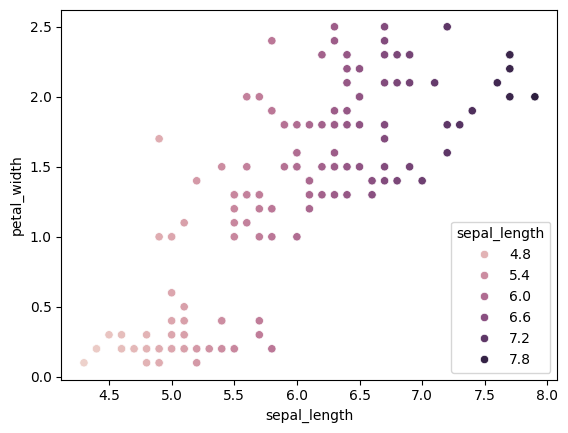

In [4]:
sns.scatterplot(data=iris_df, x='sepal_length', y='petal_width', hue='sepal_length')

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

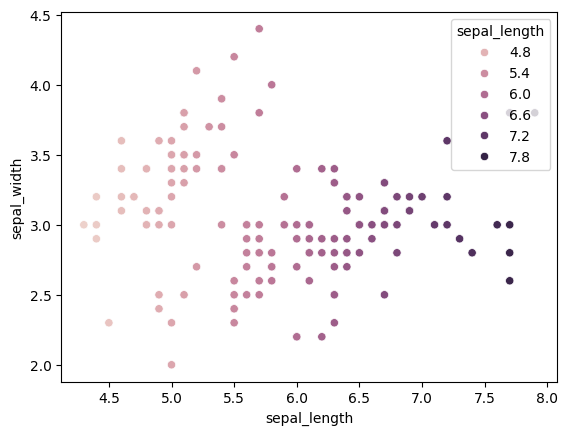

In [5]:
sns.scatterplot(data=iris_df, x='sepal_length', y='sepal_width', hue='sepal_length')

In [6]:
numeric_cols = iris_df.columns.tolist()
numeric_cols.remove('species')
numeric_cols

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [7]:
X_train = iris_df[numeric_cols]
X_train.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


# $$DBSCAN (Density-Based Spatial Clustering of Applications with Noise)$$

DBSCAN is an **unsupervised clustering algorithm** that groups together points that are **closely packed** and marks points in low-density regions as **noise (outliers)**.

Unlike K-Means, you **do not need to specify the number of clusters**.

---

## 1️⃣ Core Idea

Clusters are formed based on **density**, not distance from centroid.

If many points are close together → dense region → cluster
If a point is isolated → marked as noise

---

## 2️⃣ Important Concepts

### 1. eps (ε)

Radius around a point.

It defines:
“How far should we look to find neighboring points?”

---

### 2. min_samples

Minimum number of points required inside eps radius to form a dense region.

---

### 3. Types of Points

#### ✔ Core Point

A point having ≥ min_samples inside eps radius.

#### ✔ Border Point

Has fewer than min_samples neighbors but lies within eps of a core point.

#### ✔ Noise Point

Not a core point and not reachable from any core point.

---

## 3️⃣ How DBSCAN Works (Step-by-Step)

1. Pick a random point.
2. Check how many points lie inside its eps radius.
3. If ≥ min_samples → it becomes a core point → start forming cluster.
4. Expand cluster by including its density-reachable neighbors.
5. Continue until no more expansion possible.
6. Move to next unvisited point.
7. Points that never become part of any cluster → marked as noise.

---

## 4️⃣ Mathematical Idea

DBSCAN forms clusters based on:

Density Reachability
A point A is density-reachable from point B if:

* B is a core point
* A lies within eps of B

Clusters are connected dense regions.


You are correct. Let’s now write the **mathematical formulation of DBSCAN** properly.

---

### 1️⃣ ε–Neighborhood

For a point ( x ) in dataset ( D ):
$$
N_{\varepsilon}(x) = { y \in D \mid \text{dist}(x, y) \le \varepsilon }
$$
This means:

$$
All points ( y ) whose distance from ( x ) is less than or equal to ( \varepsilon ).
$$
---

### 2️⃣ Core Point Condition

A point ( x ) is a **core point** if:

$$
|N_{\varepsilon}(x)| \ge \text{min\_samples}
$$
Meaning:

The number of points inside its ε-neighborhood is at least `min_samples`.

---

### 3️⃣ Direct Density Reachability

A point ( y ) is **directly density-reachable** from ( x ) if:
$$
y \in N_{\varepsilon}(x) \quad \text{and} \quad x \text{ is a core point}
$$
---

### 4️⃣ Density Reachability

A point ( y ) is **density-reachable** from ( x ) if there exists a sequence of points:
$$
x = x_1, x_2, x_3, \dots, x_n = y
$$
such that:
$$
x_{i+1} \in N_{\varepsilon}(x_i)
$$
$$
and every ( x_i ) is a core point (except possibly ( y )).
$$
---

### 5️⃣ Density Connectivity

Two points ( x ) and ( y ) are density-connected if there exists a point ( z ) such that:
$$
x \text{ and } y \text{ are density-reachable from } z
$$
---

#### 6️⃣ Cluster Definition (Mathematically)

A cluster ( C \subset D ) satisfies:

1. **Maximality**
$$
   If ( x \in C ) and ( y ) is density-reachable from ( x ), then:
$$
$$
   y \in C

$$
2. **Connectivity**
$$
   For any ( x, y \in C ), they are density-connected.
$$
---

### 7️⃣ Noise Definition
$$
A point ( x \in D ) is noise if:
$$
$$
x \notin \bigcup_{i=1}^{k} C_i
$$
Meaning it does not belong to any cluster.

---

Now you can see:

* K-Means → minimizes squared distance objective
* DBSCAN → builds clusters using density connectivity rules

If you want, I can now explain how this connects to implementation intuition (which is important for interviews and ML understanding).


---

## 5️⃣ Advantages

✔ No need to specify number of clusters
✔ Can detect arbitrary shaped clusters
✔ Handles outliers automatically
✔ Works well when clusters are dense and well separated

---

## 6️⃣ Disadvantages

✘ Choosing eps is difficult
✘ Struggles when clusters have varying densities
✘ Not good for very high-dimensional data

---

## 7️⃣ Important Parameters (sklearn)

```
DBSCAN(
    eps=0.5,
    min_samples=5,
    metric='euclidean',
    algorithm='auto',
    leaf_size=30,
    p=None,
    n_jobs=None
)
```

### Parameter Meaning

* eps → neighborhood radius
* min_samples → minimum density threshold
* metric → distance measure ('euclidean', 'manhattan', etc.)
* algorithm → nearest neighbor search method
* leaf_size → tree structure parameter
* p → power parameter for Minkowski distance
* n_jobs → number of CPU cores

---

## 8️⃣ Difference from K-Means

| K-Means                    | DBSCAN           |
| -------------------------- | ---------------- |
| Requires K                 | No K required    |
| Assumes spherical clusters | Any shape        |
| Sensitive to outliers      | Detects outliers |
| Uses centroids             | Uses density     |

---

## 9️⃣ When To Use DBSCAN

Use it when:

* You don’t know number of clusters
* Data contains noise
* Clusters are irregular shape
* Density is somewhat uniform

---

In [8]:
from sklearn.cluster import DBSCAN

In [71]:
# DBSCAN(
#     eps=0.5,
#     *,
#     min_samples=5,
#     metric='euclidean',
#     metric_params=None,
#     algorithm='auto',
#     leaf_size=30,
#     p=None,
#     n_jobs=None,
# )

model = DBSCAN(eps=1,
               min_samples=2,
               n_jobs=-1)

In [72]:
model.fit(X_train)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",1
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",2
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1


In [73]:
#how to change for the attributes of the any function/object
dir(model)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_class_level_metadata_request_values',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_html_repr',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_validate_params',
 'algorithm',
 'components_',
 'core_sample_indices_',
 'eps',
 'feature_names_in_',
 'fit',
 'fit_predict',
 'get_metadata_routing',
 'get_params',
 'labels_',
 'leaf_size',
 'metric',
 'metric_params'

In [74]:
model.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [75]:
model.core_sample_indices_

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149])

<Axes: xlabel='sepal_length', ylabel='petal_length'>

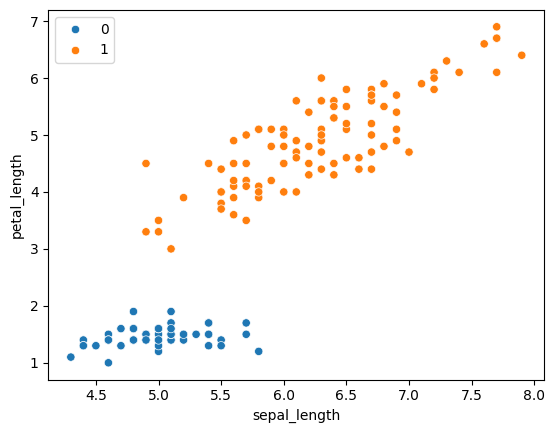

In [76]:
sns.scatterplot(data=X_train, x='sepal_length', y='petal_length', hue=model.labels_)

## Important Difference between K-Means and DBSCAN

![](assets/2026-02-09-17-54-03.png)